<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-1/ML_LAB_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression for Body Weight Prediction

## Objective

Perform Linear Regression to find the body weight of a person based on height, age, and gender.

## Dependent Variable

Weight

## Independent Variables

- Height
- Age
- Gender

## Machine Learning Model Used

Multiple Linear Regression

In [ ]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================
# 2. CREATE THE DATASET
# ============================================

data = {
    "Weight": [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    "Height": [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    "Age": [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    "Gender": [
        "Male", "Male", "Male", "Male", "Male",
        "Female", "Female", "Female", "Female", "Female"
    ]
}

df = pd.DataFrame(data)

df

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [ ]:
# ============================================
# 3. DISPLAY THE DATASET
# ============================================

print("Dataset:")
print(df)

Dataset:
   Weight  Height  Age  Gender
0      79    1.80   35    Male
1      69    1.68   39    Male
2      73    1.82   25    Male
3      95    1.70   60    Male
4      82    1.87   27    Male
5      55    1.55   18  Female
6      69    1.50   89  Female
7      71    1.78   42  Female
8      64    1.67   16  Female
9      69    1.64   52  Female


In [ ]:
# ============================================
# 4. UNDERSTAND THE DATASET
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 10
Number of columns: 4

Column names:
['Weight', 'Height', 'Age', 'Gender']


In [ ]:
# ============================================
# 5. CHECK DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  10 non-null     int64  
 1   Height  10 non-null     float64
 2   Age     10 non-null     int64  
 3   Gender  10 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 452.0+ bytes


In [ ]:
# ============================================
# 6. STATISTICAL SUMMARY
# ============================================

df.describe()

,Weight,Height,Age
count,10.000000,10.000000,10.000000
mean,72.600000,1.701000,40.300000
std,10.834103,0.118832,22.181323
min,55.000000,1.500000,16.000000
25%,69.000000,1.647500,25.500000
50%,70.000000,1.690000,37.000000
75%,77.500000,1.795000,49.500000
max,95.000000,1.870000,89.000000


In [ ]:
# ============================================
# 7. CHECK FOR MISSING VALUES
# ============================================

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Weight    0
Height    0
Age       0
Gender    0
dtype: int64


## Data Preprocessing

The `Gender` variable contains categorical values such as Male and Female.

Since Linear Regression requires numerical input, the gender values will be converted into numerical values:

- Female → 0
- Male → 1

In [ ]:
# ============================================
# 8. ENCODE THE GENDER VARIABLE
# ============================================

df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

df

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


In [ ]:
# ============================================
# 9. CHECK THE ENCODED DATA
# ============================================

print(df.head())

print("\nGender values after encoding:")
print(df["Gender"].unique())

   Weight  Height  Age  Gender
0      79    1.80   35       1
1      69    1.68   39       1
2      73    1.82   25       1
3      95    1.70   60       1
4      82    1.87   27       1

Gender values after encoding:
[1 0]


In [ ]:
# ============================================
# 10. DEFINE FEATURES AND TARGET
# ============================================

X = df[["Height", "Age", "Gender"]]

y = df["Weight"]

print("Independent Variables (X):")
print(X)

print("\nDependent Variable (y):")
print(y)

Independent Variables (X):
   Height  Age  Gender
0    1.80   35       1
1    1.68   39       1
2    1.82   25       1
3    1.70   60       1
4    1.87   27       1
5    1.55   18       0
6    1.50   89       0
7    1.78   42       0
8    1.67   16       0
9    1.64   52       0

Dependent Variable (y):
0    79
1    69
2    73
3    95
4    82
5    55
6    69
7    71
8    64
9    69
Name: Weight, dtype: int64


In [ ]:
# ============================================
# 11. SPLIT THE DATASET
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

Training data:
   Height  Age  Gender
7    1.78   42       0
2    1.82   25       1
9    1.64   52       0
4    1.87   27       1
3    1.70   60       1
6    1.50   89       0

Testing data:
   Height  Age  Gender
8    1.67   16       0
1    1.68   39       1
5    1.55   18       0
0    1.80   35       1

Training samples: 6
Testing samples: 4


In [ ]:
# ============================================
# 12. CREATE THE LINEAR REGRESSION MODEL
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# ============================================
# 13. DISPLAY MODEL COEFFICIENTS
# ============================================

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -133.6732014809156

Coefficients:
Height : 99.05019302959039
Age : 0.6704516652303933
Gender : 14.016159169150153


In [ ]:
# ============================================
# 14. DISPLAY REGRESSION EQUATION
# ============================================

print(
    "Weight =",
    round(model.intercept_, 4),
    "+",
    round(model.coef_[0], 4), "* Height",
    "+",
    round(model.coef_[1], 4), "* Age",
    "+",
    round(model.coef_[2], 4), "* Gender"
)

Weight = -133.6732 + 99.0502 * Height + 0.6705 * Age + 14.0162 * Gender


In [ ]:
# ============================================
# 15. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

print("Predicted weights:")
print(y_pred)

Predicted weights:
[42.46784752 72.89489692 31.92272769 82.09911342]


In [ ]:
# ============================================
# 16. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

comparison = pd.DataFrame({
    "Actual Weight": y_test.values,
    "Predicted Weight": y_pred
})

comparison

,Actual Weight,Predicted Weight
0,64,42.467848
1,69,72.894897
2,55,31.922728
3,79,82.099113


In [ ]:
# ============================================
# 17. MODEL EVALUATION
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 12.900858783802384
Mean Squared Error (MSE): 255.24220342254034
Root Mean Squared Error (RMSE): 15.976301306076458
R² Score: -2.394742522660553


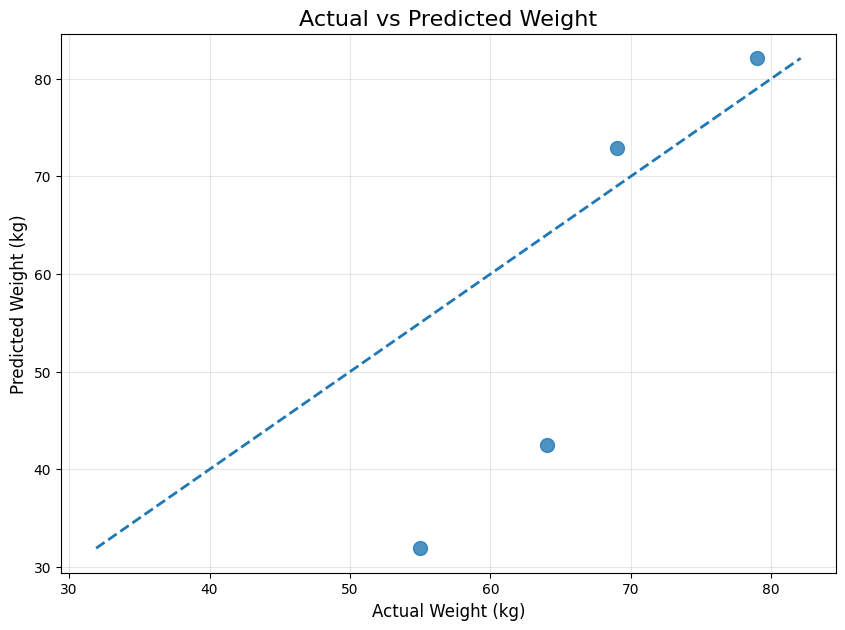

In [ ]:
# ============================================
# 18. ACTUAL VS PREDICTED WEIGHT GRAPH
# ============================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    alpha=0.8
)

# Reference line: Perfect Prediction
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Weight (kg)", fontsize=12)
plt.ylabel("Predicted Weight (kg)", fontsize=12)

plt.title(
    "Actual vs Predicted Weight",
    fontsize=16
)

plt.grid(True, alpha=0.3)

plt.show()

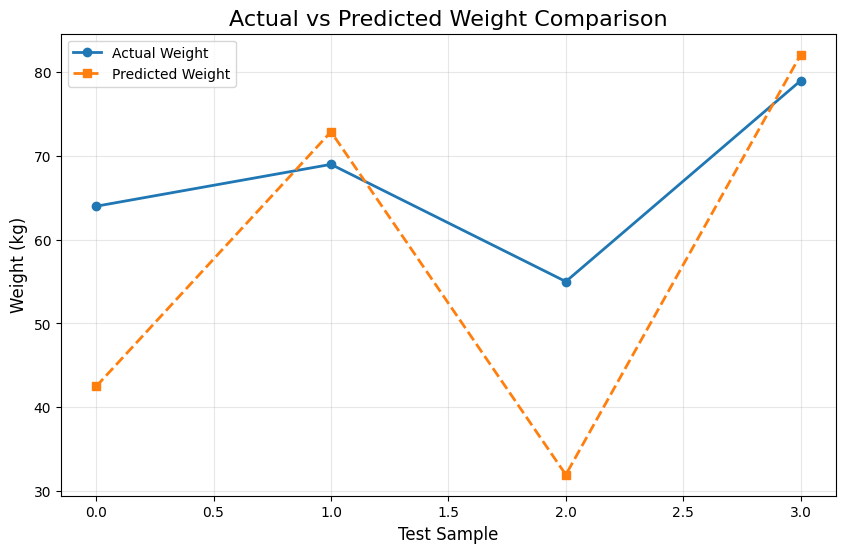

In [ ]:
# ============================================
# 19. ACTUAL VS PREDICTED COMPARISON GRAPH
# ============================================

comparison = pd.DataFrame({
    "Actual Weight": y_test.values,
    "Predicted Weight": y_pred
})

comparison = comparison.reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(
    comparison.index,
    comparison["Actual Weight"],
    marker="o",
    linewidth=2,
    label="Actual Weight"
)

plt.plot(
    comparison.index,
    comparison["Predicted Weight"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Predicted Weight"
)

plt.xlabel("Test Sample", fontsize=12)
plt.ylabel("Weight (kg)", fontsize=12)

plt.title(
    "Actual vs Predicted Weight Comparison",
    fontsize=16
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

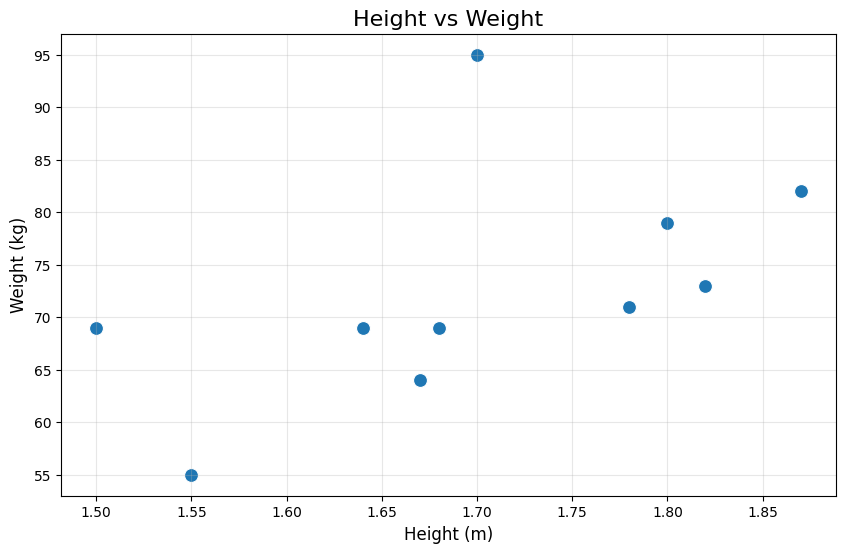

In [ ]:
# ============================================
# 20. HEIGHT VS WEIGHT GRAPH
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    s=100
)

plt.xlabel("Height (m)", fontsize=12)
plt.ylabel("Weight (kg)", fontsize=12)

plt.title(
    "Height vs Weight",
    fontsize=16
)

plt.grid(True, alpha=0.3)

plt.show()

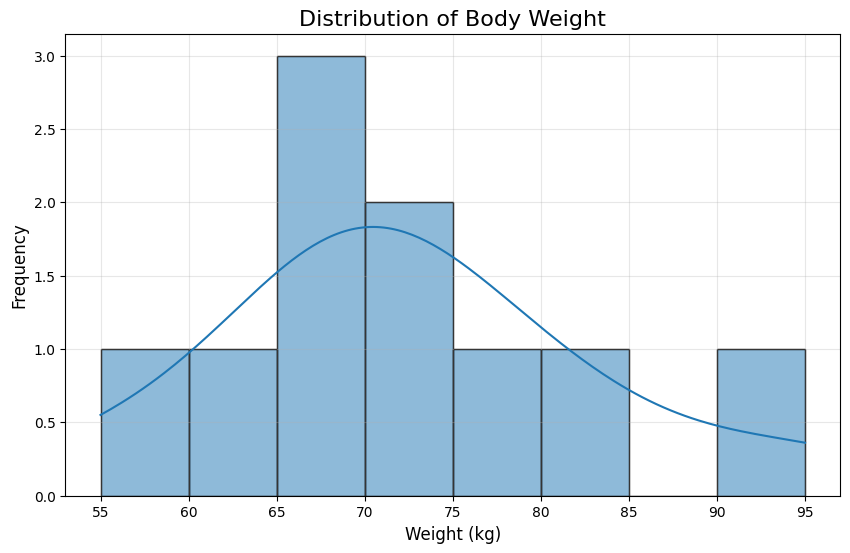

In [ ]:
# ============================================
# 21. WEIGHT DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Weight"],
    bins=8,
    kde=True
)

plt.xlabel("Weight (kg)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.title(
    "Distribution of Body Weight",
    fontsize=16
)

plt.grid(True, alpha=0.3)

plt.show()

### Observation

The predictive performance of the Linear Regression model is not very high because the current dataset used has only 10 observations. The dataset size is small enough that the train/test split affects the performance of the model in learning the relationship between the height, age, gender, and body weight.

The interpretation of the R² value should, therefore, be done with some caution. A larger dataset with more observations would have been required to develop a better prediction model for body weight.

# Conclusion

Multiple Linear Regression model was built for predicting the body weight of a person on the basis of Height, Age, and Gender independent variables.

Gender was treated as a categorical variable that was encoded as 0 for Female and 1 for Male.

The dataset was split into Training and Testing datasets and a Linear Regression model was trained and tested with the help of MAE, MSE, RMSE, and R² score.

The trained model can also be used for predicting the body weight of any new person on the basis of height, age, and gender.

Hence, Multiple Linear Regression is one way to model the body weight prediction problem.